
# Uplift Modeling: Who Actually Benefits from Treatment?

*A lecture note on heterogeneous treatment effects, meta-learners, and why
"the average effect worked" is not the same question as "who should we
target."*

---

## 1. Intro: the marketing team's puzzle

A marketing team runs a randomized experiment: half of their customers get a
promotional email, half don't. A month later they check conversions and find
that the email group converted more often, on average. Great — the campaign
"worked." So they roll it out to everyone.

Six months later, unsubscribe rates are up, some loyal customers are
irritated, and a chunk of the marketing budget went to people who would have
converted anyway. What happened?

**The average treatment effect (ATE) was real, but it was an average over
four very different kinds of people:**

- **Persuadables** — people who convert *only if* they get the email. This
  is the group the campaign should be built for.
- **Sure things** — people who were going to convert regardless. Sending
  them an email is a wasted incentive (and, if there's a discount attached,
  wasted margin).
- **Lost causes** — people who won't convert no matter what. Also a wasted
  send, just a cheaper one.
- **Sleeping dogs** — people who convert *less* often if you email them
  (annoyed, unsubscribe, or actively repelled by the pitch). For this group
  the "treatment" backfires.

A single ATE number cannot tell these four groups apart — it just averages
them together. The [Fundamental Problem of Causal
Inference](../fundamental-problem-of-causal-inference/tutorial.ipynb)
tutorial in this domain flagged exactly this in its own limitations section:
*"reporting only an ATE can mask enormous effect heterogeneity."* This
tutorial is about closing that gap: instead of asking "what is the average
effect of treatment?", we ask **"what is the effect of treatment for a unit
that looks like *this*?"** — a question with a different answer for every
customer, patient, or claimant, and one you can actually act on.

**By the end of this tutorial you'll be able to:**

- State the **Conditional Average Treatment Effect (CATE)**, $\tau(x)$,
  precisely, and explain how it relates back to the ATE from the
  fundamental-problem tutorial.
- Explain, with a derivation, why targeting the people with the highest
  *predicted probability of converting* is not the same as targeting the
  people with the highest *uplift* — the **response-modeling fallacy**.
- Build and compare **meta-learners** (T-learner, S-learner, and the idea
  behind the X-learner) — the standard toolkit for estimating $\tau(x)$ from
  data, using both hand-written `scikit-learn` code and the practitioner
  library **EconML**.
- Evaluate a targeting model the way practitioners actually do: with a
  **qini curve**, not a held-out accuracy score.
- Estimate real heterogeneous treatment effects on a real randomized
  email-marketing experiment, and know exactly what assumption the whole
  exercise still depends on.



## 2. The idea, intuitively

Let's put numbers on the four customer archetypes from the intro. Imagine we
could see (god's-eye view, same trick as the fundamental-problem tutorial)
each customer's true probability of converting *if emailed* and *if not
emailed*:

| Archetype     | P(convert \| emailed) | P(convert \| not emailed) | True uplift |
|---------------|:---:|:---:|:---:|
| Persuadable   | 0.55 | 0.15 | **+0.40** |
| Sure thing    | 0.90 | 0.88 | +0.02 |
| Lost cause    | 0.05 | 0.04 | +0.01 |
| Sleeping dog  | 0.30 | 0.55 | **−0.25** |

**Here's the trap a naive analysis falls into.** If you built a plain
"response model" — a classifier trained to predict *P(convert | treated)*
and used its score to decide who to target — the **sure thing** customer
would rank near the top of your list (score 0.90!). But their *uplift* is
almost zero: they were converting anyway. Meanwhile the **persuadable**
customer might have a lower raw response score (0.55) but by far the
largest genuine *effect* of being emailed. A response model answers "who is
likely to convert," which is a fundamentally different question from "who
converts *because of* the email."

Let's see this directly with a small illustrative example.


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

archetypes = ["Persuadable", "Sure thing", "Lost cause", "Sleeping dog"]
p_treated  = np.array([0.55, 0.90, 0.05, 0.30])
p_control  = np.array([0.15, 0.88, 0.04, 0.55])
uplift     = p_treated - p_control

toy = pd.DataFrame({"archetype": archetypes,
                     "P(convert | treated)": p_treated,
                     "P(convert | control)": p_control,
                     "true uplift tau(x)": uplift})
print(toy.to_string(index=False))


   archetype  P(convert | treated)  P(convert | control)  true uplift tau(x)
 Persuadable                  0.55                  0.15                0.40
  Sure thing                  0.90                  0.88                0.02
  Lost cause                  0.05                  0.04                0.01
Sleeping dog                  0.30                  0.55               -0.25



**Takeaway:** a response model ranks by the *treated* column alone. An
uplift model ranks by the *gap* between the two columns. Those are
different rankings, and the difference is exactly the budget a marketing
team wastes (or the harm a naive rollout causes) when it skips uplift
modeling. Let's visualize the gap directly.


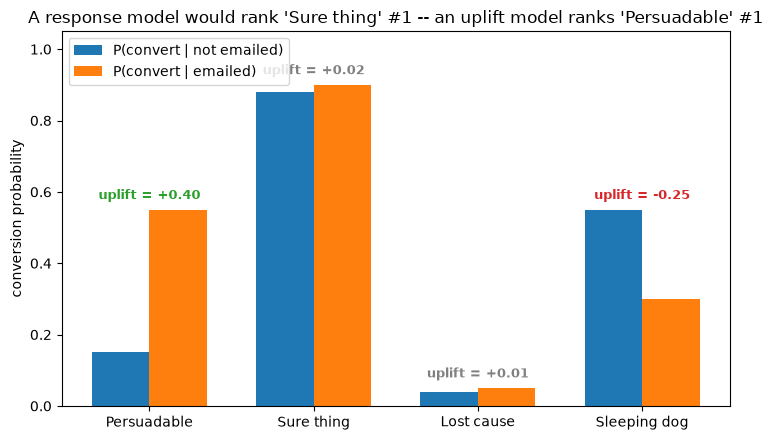

In [2]:

fig, ax = plt.subplots(figsize=(7.5, 4.5))
x = np.arange(len(archetypes))
width = 0.35
ax.bar(x - width/2, p_control, width, label="P(convert | not emailed)", color="tab:blue")
ax.bar(x + width/2, p_treated, width, label="P(convert | emailed)", color="tab:orange")
for i, u in enumerate(uplift):
    ax.annotate(f"uplift = {u:+.2f}", (i, max(p_treated[i], p_control[i]) + 0.03),
                ha="center", fontsize=9, fontweight="bold",
                color="tab:green" if u > 0.1 else ("tab:red" if u < 0 else "gray"))
ax.set_xticks(x); ax.set_xticklabels(archetypes)
ax.set_ylabel("conversion probability")
ax.set_ylim(0, 1.05)
ax.set_title("A response model would rank 'Sure thing' #1 -- an uplift model ranks 'Persuadable' #1")
ax.legend(loc="upper left")
plt.tight_layout()
plt.savefig("toy_archetypes.png", dpi=130)
plt.show()



The "Sure thing" bars are tall in *both* colors — high response score, tiny
uplift. The "Sleeping dog" bars actually go *down* under treatment — a
textbook case where treating someone hurts. Only "Persuadable" has a big
gap between the two bars. **Uplift modeling is the machinery for finding
the persuadables (and avoiding the sleeping dogs) using data, instead of
guessing.**



## 3. Going deeper: the formal definition

### 3.1 The CATE, and how it relates to the ATE

Using the same potential-outcomes notation as the fundamental-problem
tutorial — $Y_i(1)$, $Y_i(0)$ are unit $i$'s potential outcomes under
treatment and control — define the **Conditional Average Treatment Effect**
as a function of covariates $x$:

$$\tau(x) = \mathbb{E}\big[Y(1) - Y(0) \mid X = x\big].$$

This is the *average* effect among all units that share covariate value
$x$ (it is still an average, not the unobservable individual effect
$\tau_i = Y_i(1)-Y_i(0)$ from the fundamental-problem tutorial — no amount
of modeling recovers that). What makes $\tau(x)$ useful is that it is a
**function**, not a single number: it can be large for one kind of unit and
near zero or negative for another.

The ATE is recovered by averaging the CATE over the distribution of
covariates in the population:

$$\text{ATE} = \mathbb{E}_x\big[\tau(x)\big] = \int \tau(x)\, p(x)\, dx.$$

So the ATE is not *wrong* — it is the CATE's population average, and
therefore always a real, well-defined number. It is just not enough
information to *target* anyone, because it throws away every bit of the
shape of $\tau(x)$ that made the marketing team's rollout backfire on the
sleeping dogs in section 2.

### 3.2 The response-modeling fallacy, precisely

Let $T \in \{0,1\}$ be the treatment indicator. A "response model," as
built in a lot of applied marketing/credit-risk work, estimates

$$\mu_1(x) = P(Y=1 \mid X=x, T=1) \qquad \text{(or } \mathbb{E}[Y\mid X=x,T=1]\text{ for continuous } Y\text{)},$$

and targets the units with the highest $\mu_1(x)$. The **uplift** — what we
actually want — is

$$\tau(x) = \mu_1(x) - \mu_0(x), \qquad \mu_0(x) = \mathbb{E}[Y \mid X=x, T=0].$$

The fallacy is treating $\mu_1(x)$ as a proxy for $\tau(x)$. It is not: two
units can have identical $\mu_1(x)$ and wildly different $\tau(x)$, because
$\mu_1(x)$ says nothing about $\mu_0(x)$. Concretely, the "sure thing" in
section 2 has $\mu_1(x)=0.90$ and $\mu_0(x)=0.88$, so $\tau(x)=0.02$; the
"persuadable" has a *lower* $\mu_1(x)=0.55$ but $\mu_0(x)=0.15$, so
$\tau(x)=0.40$ — twenty times larger. Ranking by $\mu_1(x)$ alone gets the
priority order backwards. This is not a hypothetical: it is the single most
common mistake in applied "propensity to buy" / "risk score" targeting
systems, and it is exactly why uplift modeling exists as its own
subfield rather than being "just classification."

### 3.3 The T-learner

The most direct way to estimate $\tau(x)$ is to estimate $\mu_1(x)$ and
$\mu_0(x)$ **separately**, each with its own model, fit only on the
relevant arm of the data:

$$\hat\mu_1(x) = \text{model fit on } \{(x_i, y_i) : T_i = 1\}, \qquad
  \hat\mu_0(x) = \text{model fit on } \{(x_i, y_i) : T_i = 0\},$$
$$\hat\tau_T(x) = \hat\mu_1(x) - \hat\mu_0(x).$$

This is the **T-learner** ("T" for "two models"). It is simple and lets
each model specialize to its own arm, but it has a known weakness: each
model only ever sees its own arm's data, so if the control arm is much
smaller than the treatment arm (as it will be in this tutorial's dataset),
$\hat\mu_0(x)$ is estimated with much less data and much more noise than
$\hat\mu_1(x)$ — and that noise propagates directly into $\hat\tau_T(x)$.

### 3.4 The S-learner

The **S-learner** ("S" for "single model") instead folds $T$ in as just
another feature and fits **one** model on everyone:

$$\hat\mu(x, t) = \text{model fit on } \{(x_i, T_i, y_i)\}_{i=1}^n,$$
$$\hat\tau_S(x) = \hat\mu(x, 1) - \hat\mu(x, 0).$$

The S-learner pools all the data into one model, which helps when the
treated/control split is imbalanced, but it has its own failure mode:
flexible models (trees, boosted ensembles) can effectively ignore a single
binary feature $T$ if it isn't a strong global predictor of $Y$, which
biases $\hat\tau_S(x)$ toward zero — the model "regularizes away" the
treatment effect. Neither meta-learner dominates the other in every
setting; which one wins is itself an active area of research (Künzel et
al., 2019; Curth & van der Schaar, 2021), which we return to in
Limitations.

### 3.5 The X-learner, and the propensity-score connection

The **X-learner** (Künzel, Sekhon, Bickel & Yu, 2019) tries to fix the
T-learner's data-imbalance weakness. The idea, in three steps:

1. Fit $\hat\mu_1(x)$ and $\hat\mu_0(x)$ exactly as in the T-learner.
2. **Impute the missing potential outcome** for every unit using the
   *other* arm's model, and take the resulting per-unit difference as an
   *imputed* individual effect:
   $$\tilde D_i^1 = Y_i - \hat\mu_0(X_i) \ \text{ for treated units}, \qquad
     \tilde D_i^0 = \hat\mu_1(X_i) - Y_i \ \text{ for control units}.$$
   (This is the same "fill in the missing potential outcome with a model"
   move used throughout observational causal inference — you cannot
   observe $Y_i(0)$ for a treated unit, so you predict it.)
3. Fit two more models, $\hat\tau_1(x)$ on the treated group's $\tilde
   D^1$ and $\hat\tau_0(x)$ on the control group's $\tilde D^0$, and combine
   them with a weight $g(x) \in [0,1]$:
   $$\hat\tau_X(x) = g(x)\,\hat\tau_0(x) + (1-g(x))\,\hat\tau_1(x).$$

The recommended choice for $g(x)$ is the **propensity score**,
$e(x) = P(T=1\mid X=x)$ — the exact same quantity that drives the
propensity-score-matching tutorial in this domain. The intuition is
identical to matching's: when the control group is small ($e(x)$ close to
1, as in this tutorial's dataset), $\hat\tau_0(x)$ (estimated from the
scarce controls) is noisier, so the X-learner **downweights it** and leans
more on $\hat\tau_1(x)$ — using the propensity score to decide *how much to
trust each arm's model*, rather than to reweight a regression as in IPW.
This is why the X-learner tends to outperform the plain T-learner exactly
in the class of problems this tutorial's dataset represents: unbalanced
treatment/control group sizes.

### 3.6 The assumption none of this escapes

Every meta-learner above is built entirely out of estimating $\mathbb{E}[Y
\mid X, T]$ from observed data and taking differences. That is only a valid
estimate of $\tau(x) = \mathbb{E}[Y(1)-Y(0)\mid X=x]$ under the **same
ignorability (unconfoundedness) assumption** from the fundamental-problem
tutorial, now conditional on $X$:

$$\{Y(0), Y(1)\} \perp T \mid X.$$

Uplift modeling does **not** relax this requirement — it estimates a
*richer* object ($\tau(x)$ instead of a single ATE number) under the exact
same assumption the whole domain rests on. When treatment is randomized (as
it is in this tutorial's dataset, and as it was in the NSW experiment),
ignorability holds by construction for every $x$, and every meta-learner
above is on solid ground. If treatment were instead observational, you
would need everything the propensity-score-matching tutorial covers
(confounder adjustment, common support) *before* trusting any $\hat\tau(x)$
— violating ignorability biases CATE estimates too, just with no single
ATE-style number to sanity-check it against (more on this in Limitations).



## 4. Visuals: what a CATE function actually looks like

Before touching the real dataset, it helps to see $\tau(x)$ as a genuine
*function* of a covariate, not just four discrete archetypes. Below is a
small synthetic example (used only to illustrate the shape of $\tau(x)$ —
the real analysis starts in section 5): imagine a promotion whose effect on
purchase probability depends smoothly on a customer's account tenure. We
generate synthetic treated/control outcomes from a known, tenure-dependent
uplift function, then show that a single ATE line completely hides the
underlying shape.


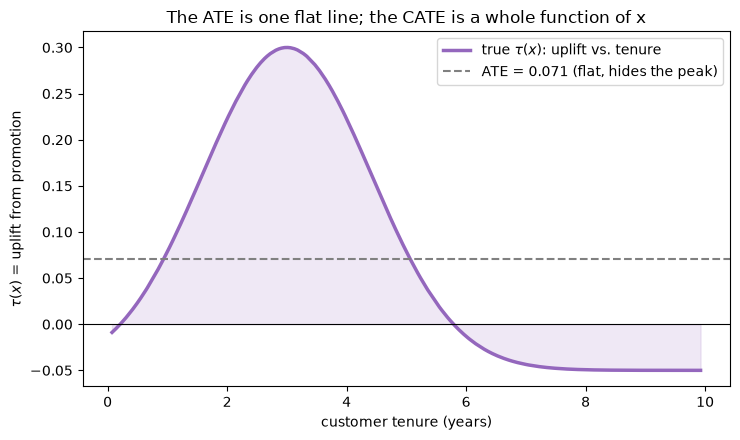

In [3]:

rng = np.random.default_rng(42)
n_toy = 400
tenure = rng.uniform(0, 10, n_toy)          # years as a customer
true_tau = 0.35 * np.exp(-((tenure - 3) ** 2) / 4) - 0.05   # peaks around tenure=3, dips slightly elsewhere

fig, ax = plt.subplots(figsize=(7.5, 4.5))
order = np.argsort(tenure)
ax.plot(tenure[order], true_tau[order], color="tab:purple", lw=2.5, label=r"true $\tau(x)$: uplift vs. tenure")
ax.axhline(true_tau.mean(), color="gray", linestyle="--", label=f"ATE = {true_tau.mean():.3f} (flat, hides the peak)")
ax.fill_between(tenure[order], 0, true_tau[order], alpha=0.15, color="tab:purple")
ax.axhline(0, color="black", lw=0.8)
ax.set_xlabel("customer tenure (years)")
ax.set_ylabel(r"$\tau(x)$ = uplift from promotion")
ax.set_title("The ATE is one flat line; the CATE is a whole function of x")
ax.legend()
plt.tight_layout()
plt.savefig("cate_shape_illustration.png", dpi=130)
plt.show()



The dashed line is the single number a plain ATE analysis reports. The
purple curve is what's actually happening: mid-tenure customers respond
strongly, brand-new and very-long-tenure customers respond weakly or even
slightly negatively. **A targeting policy built from the dashed line
targets everyone equally; a targeting policy built from the purple curve
targets the peak.** Estimating that curve — not from a known formula like
here, but from real, noisy data — is exactly what the rest of this
tutorial does.



## 5. Implementation: a real randomized email-marketing experiment

**Data**: `invest_email_rnd.csv`, from Matheus Facure's open-source book
*Causal Inference for the Brave and True*. It is a randomized experiment
run by an investment platform: 15,000 customers, each independently
randomized into receiving (or not receiving) up to three separate
promotional emails about the platform, with a binary conversion outcome.
Columns: `age`, `income`, `insurance`, `invested` (pre-campaign covariates)
and `em1`, `em2`, `em3`, `converted`.

We don't yet know exactly what `em1`/`em2`/`em3` represent relative to each
other, or whether `invested` is a covariate or an outcome — so, per this
repo's standard, we inspect before assuming.


In [4]:

df = pd.read_csv(
    "https://raw.githubusercontent.com/matheusfacure/python-causality-handbook/"
    "master/causal-inference-for-the-brave-and-true/data/invest_email_rnd.csv"
)
print(df.shape)
df.head()


(15000, 8)


,age,income,insurance,invested,em1,em2,em3,converted
0,44.1,5483.80,6155.29,14294.81,0,1,1,0
1,39.8,2737.92,50069.40,7468.15,1,0,0,0
2,49.0,2712.51,5707.08,5095.65,1,0,1,1
3,39.7,2326.37,15657.97,6345.20,1,1,1,0
4,35.3,2787.26,27074.44,14114.86,1,1,1,0


In [5]:

df.describe().round(2)


,age,income,insurance,invested,em1,em2,em3,converted
count,15000.00,15000.00,15000.00,15000.00,15000.0,15000.0,15000.0,15000.00
mean,42.06,4674.38,29481.54,9926.52,0.5,0.2,0.9,0.14
std,3.97,4180.34,35091.38,11196.37,0.5,0.4,0.3,0.35
min,24.30,500.02,0.01,44.54,0.0,0.0,0.0,0.00
25%,39.40,1681.63,5677.45,2859.24,0.0,0.0,1.0,0.00
50%,42.00,3375.23,17113.96,6113.27,1.0,0.0,1.0,0.00
75%,44.80,6335.10,40355.29,12752.21,1.0,0.0,1.0,0.00
max,58.20,37946.51,325811.76,159862.45,1.0,1.0,1.0,1.00



### 5.1 Deciding the treatment and outcome definition

Two things need to be pinned down empirically before any modeling:

1. **Are `em1`, `em2`, `em3` different treatment arms of a single
   randomization, or three independently-randomized email sends?**
2. **Is `converted` the outcome, or is `invested` the outcome?**


In [6]:

print("Mean send rate per email:")
print(df[["em1", "em2", "em3"]].mean().round(3))
print("\nPairwise correlation between the three email indicators:")
print(df[["em1", "em2", "em3"]].corr().round(3))
print("\nDistribution of 'invested' (candidate outcome #1):")
print(df["invested"].describe().round(2))
print("\nMean of 'converted' (candidate outcome #2), a 0/1 flag:", df["converted"].mean().round(4))


Mean send rate per email:
em1    0.504
em2    0.203
em3    0.901
dtype: float64

Pairwise correlation between the three email indicators:
       em1    em2    em3
em1  1.000 -0.009  0.008
em2 -0.009  1.000  0.002
em3  0.008  0.002  1.000

Distribution of 'invested' (candidate outcome #1):
count     15000.00
mean       9926.52
std       11196.37
min          44.54
25%        2859.24
50%        6113.27
75%       12752.21
max      159862.45
Name: invested, dtype: float64

Mean of 'converted' (candidate outcome #2), a 0/1 flag: 0.1418



The three email indicators are essentially **uncorrelated with each other**
(all pairwise correlations near 0) and are sent at different rates (50%,
20%, 90%) — the signature of three *independently randomized* campaigns,
not three mutually exclusive arms of one randomization. `invested` is a
continuous, wide-ranging dollar figure (from \$44 to over \$150,000) with
no special mass at 0 or 1 — it reads as a **pre-existing covariate**
(the customer's investment balance elsewhere), not something a single
email plausibly moves in that range. `converted` is a clean binary flag
with a base rate of 14.2% — the natural outcome variable for "did this
person open a new investment account after the campaign."

**The interpretive choice we're making, stated plainly:** since the three
emails are independently randomized nudges toward the same underlying
action (opening an account), we define the treatment as **received at
least one promotional email** (`any_email`) versus **received none**, and
the outcome as **`converted`**. This is a defensible, honestly-stated
simplification — it estimates the effect of "being in this platform's
email-marketing funnel at all" rather than the effect of any one specific
email variant, which is the practically relevant question for a "should we
run this email program on this customer or not" targeting decision (the
one this tutorial is about). We keep `age`, `income`, `insurance`, and
`invested` as covariates throughout.


In [7]:

df["any_email"] = (df[["em1", "em2", "em3"]].sum(axis=1) > 0).astype(int)
print(df["any_email"].value_counts().rename({0: "no email (control)", 1: "any email (treated)"}))
print(f"\nControl group is {df['any_email'].mean():.1%} of the sample treated, "
      f"{(1 - df['any_email'].mean()):.1%} control -- a notably imbalanced split "
      "we'll need to keep in mind for every estimator below.")


any_email
any email (treated)    14407
no email (control)       593
Name: count, dtype: int64

Control group is 96.0% of the sample treated, 4.0% control -- a notably imbalanced split we'll need to keep in mind for every estimator below.



### 5.2 Covariate balance check

Because `any_email` is built from three *independently randomized*
indicators, it should itself still be independent of pre-treatment
covariates. Same "Table 1" check as the fundamental-problem tutorial.


In [8]:

from scipy import stats

covariates = ["age", "income", "insurance", "invested"]
rows = []
treat_grp = df[df.any_email == 1]
ctrl_grp = df[df.any_email == 0]
for c in covariates:
    t_mean, c_mean = treat_grp[c].mean(), ctrl_grp[c].mean()
    tstat, pval = stats.ttest_ind(treat_grp[c], ctrl_grp[c], equal_var=False)
    rows.append({"covariate": c, "treated mean": round(t_mean, 2),
                 "control mean": round(c_mean, 2), "p-value": round(pval, 3)})
balance = pd.DataFrame(rows)
print(balance.to_string(index=False))
print(f"\n{(balance['p-value'] < 0.05).sum()} of {len(balance)} covariates differ at p<0.05 "
      "-- consistent with randomization (one borderline result out of four is within chance).")


covariate  treated mean  control mean  p-value
      age         42.05         42.07    0.913
   income       4661.97       4975.93    0.103
insurance      29470.30      29754.57    0.847
 invested       9887.91      10864.69    0.042

1 of 4 covariates differ at p<0.05 -- consistent with randomization (one borderline result out of four is within chance).



### 5.3 Baseline: the overall ATE

Before estimating any heterogeneity, replicate the baseline every earlier
tutorial in this domain starts with: the simple, population-average
effect, with a confidence interval.


In [9]:

import statsmodels.formula.api as smf

naive_ate = treat_grp["converted"].mean() - ctrl_grp["converted"].mean()
print(f"Difference in conversion rates (naive ATE) = {naive_ate:+.4f}")

ate_model = smf.ols("converted ~ any_email", data=df).fit(cov_type="HC1")
ci_low, ci_high = ate_model.conf_int().loc["any_email"]
print(f"ATE = {ate_model.params['any_email']:+.4f}   "
      f"95% CI = [{ci_low:+.4f}, {ci_high:+.4f}]   p = {ate_model.pvalues['any_email']:.2e}")


Difference in conversion rates (naive ATE) = +0.0792
ATE = +0.0792   95% CI = [+0.0584, +0.0999]   p = 7.87e-14



That single number says "on average, emailing someone raises their
conversion probability by a few percentage points." It's a real, precisely
estimated, causal effect (ignorability holds by construction here, exactly
as in section 3.6). It says nothing about *whom* to email. Now we build the
tools that do.

### 5.4 A T-learner from scratch (`scikit-learn`)

We hold out a test set specifically so the qini curve in section 5.6
evaluates the model honestly, on data it never trained on.


In [10]:

from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor

features = ["age", "income", "insurance", "invested"]

train_df, test_df = train_test_split(df, test_size=0.4, random_state=0, stratify=df["any_email"])

train_treat = train_df[train_df.any_email == 1]
train_ctrl = train_df[train_df.any_email == 0]

# Two separate outcome models: one trained only on treated units, one only on control units.
mu1_model = GradientBoostingRegressor(max_depth=3, n_estimators=200, learning_rate=0.05, random_state=0)
mu0_model = GradientBoostingRegressor(max_depth=3, n_estimators=200, learning_rate=0.05, random_state=0)
mu1_model.fit(train_treat[features], train_treat["converted"])
mu0_model.fit(train_ctrl[features], train_ctrl["converted"])

# Predict BOTH potential outcomes for every unit in the test set, then take the difference.
mu1_hat = mu1_model.predict(test_df[features])
mu0_hat = mu0_model.predict(test_df[features])
tau_hat_T = mu1_hat - mu0_hat

test_df = test_df.copy()
test_df["tau_hat_T"] = tau_hat_T
print(f"T-learner trained on {len(train_treat)} treated / {len(train_ctrl)} control units.")
print(f"Predicted CATE on test set: mean={tau_hat_T.mean():+.4f}, "
      f"min={tau_hat_T.min():+.4f}, max={tau_hat_T.max():+.4f}, std={tau_hat_T.std():.4f}")


T-learner trained on 8644 treated / 356 control units.
Predicted CATE on test set: mean=+0.0794, min=-0.8145, max=+1.0965, std=0.1252


Notice the mean of $\hat\tau_T(x)$ across the test set should land close to
the ATE from section 5.3 — that's a useful sanity check (the CATE
*averages back* to the ATE, per section 3.1) — while the spread (std, min,
max) is the part a single ATE number could never show you. One honest
wrinkle: the min/max above fall outside $[-1, 1]$, because
`GradientBoostingRegressor` fit on a 0/1 target is not a calibrated
probability model — it can extrapolate past the valid range for a handful
of unusual individual units. This is a real, common practitioner gotcha
with regression-based meta-learners on binary outcomes (a
probability-calibrated classifier avoids it, at the cost of the
`.predict_proba` plumbing most meta-learner APIs don't wire up by
default); it doesn't change the *ranking* the qini curve below evaluates,
but it's a reason not to over-read any single unit's raw $\hat\tau$ value.

### 5.5 The same estimate from EconML

`EconML` (Battocchi et al., Microsoft Research) is the practitioner-grade
library for this: it implements the meta-learners from section 3 (and much
more, like the doubly-robust and causal-forest estimators referenced in
Wager & Athey, 2018) behind a consistent `.fit(Y, T, X=...)` /
`.effect(X)` API. We use its `TLearner` with the same kind of base model as
our from-scratch version, as a check that our hand-rolled implementation
isn't doing anything unusual.


In [11]:

from econml.metalearners import TLearner

econml_tlearner = TLearner(
    models=GradientBoostingRegressor(max_depth=3, n_estimators=200, learning_rate=0.05, random_state=0)
)
econml_tlearner.fit(
    Y=train_df["converted"].values,
    T=train_df["any_email"].values,
    X=train_df[features].values,
)
tau_hat_econml = econml_tlearner.effect(test_df[features].values)
test_df["tau_hat_econml"] = tau_hat_econml

corr = np.corrcoef(test_df["tau_hat_T"], test_df["tau_hat_econml"])[0, 1]
print(f"EconML TLearner predicted CATE: mean={tau_hat_econml.mean():+.4f}, "
      f"min={tau_hat_econml.min():+.4f}, max={tau_hat_econml.max():+.4f}")
print(f"Correlation between our from-scratch T-learner and EconML's TLearner predictions: {corr:.3f}")


EconML TLearner predicted CATE: mean=+0.0794, min=-0.8145, max=+1.0965
Correlation between our from-scratch T-learner and EconML's TLearner predictions: 1.000


C:\Users\thoma\cs-ai-tutorials\.venv\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(



A high correlation here is reassuring (same meta-learner idea, same base
model family, should give similar answers) — it is not proof the estimates
are *right*, only that our from-scratch code matches a maintained library's
implementation of the same algorithm. Section 6/7 covers how to actually
check whether a CATE estimate is any good.

### 5.6 The distribution of estimated CATE: seeing the heterogeneity

This is the payoff visual: instead of the ATE's single number, we now have
one $\hat\tau(x_i)$ per customer. Plotting their distribution shows the
heterogeneity directly.


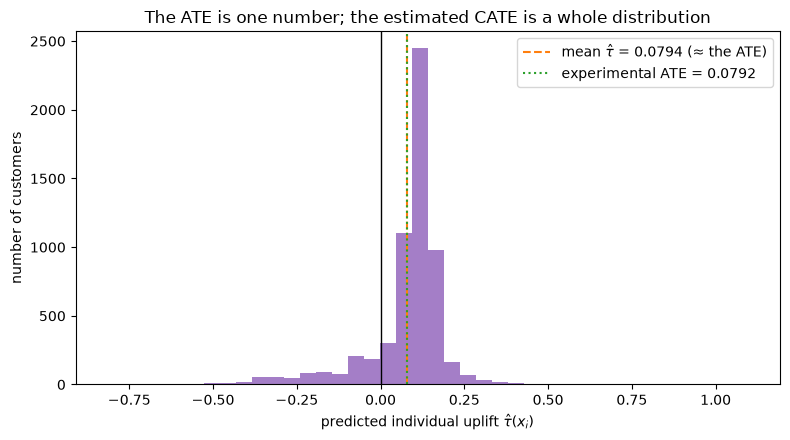

In [12]:

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(test_df["tau_hat_T"], bins=40, color="tab:purple", alpha=0.85)
ax.axvline(0, color="black", lw=1)
ax.axvline(test_df["tau_hat_T"].mean(), color="tab:orange", linestyle="--",
           label=f"mean $\\hat\\tau$ = {test_df['tau_hat_T'].mean():.4f} (≈ the ATE)")
ax.axvline(ate_model.params["any_email"], color="tab:green", linestyle=":",
           label=f"experimental ATE = {ate_model.params['any_email']:.4f}")
ax.set_xlabel(r"predicted individual uplift $\hat\tau(x_i)$")
ax.set_ylabel("number of customers")
ax.set_title("The ATE is one number; the estimated CATE is a whole distribution")
ax.legend()
plt.tight_layout()
plt.savefig("cate_distribution.png", dpi=130)
plt.show()



### 5.7 The qini curve: evaluating a targeting model for real

Held-out accuracy doesn't apply here — we never observe a unit's *true*
uplift to score a prediction against (the fundamental problem again, now
biting at the individual level). The standard evaluation tool instead is
the **qini curve** (Radcliffe & Surry, 2011): rank test-set units by
predicted uplift $\hat\tau(x_i)$, then, for the top $t$ fraction of the
population, compute the actual **incremental number of conversions**
attributable to treatment in that slice, adjusting for the (possibly
unequal) number of treated vs. control units in it:

$$\text{Qini}(t) = R_1(t) - R_0(t)\cdot\frac{N_1(t)}{N_0(t)},$$

where, within the top-$t$-fraction slice (sorted by predicted uplift,
descending), $N_1(t)$/$N_0(t)$ are the number of treated/control units and
$R_1(t)$/$R_0(t)$ are their total number of conversions. The second term
rescales the control group's conversions up to what they *would* sum to if
the control group were the same size as the treated group in that slice —
so $\text{Qini}(t)$ is directly interpretable as "how many extra
conversions did treatment cause among the top-$t$-ranked units." A model
with real ranking power should front-load conversions into the top
fractions, producing a qini curve that rises well above the **random
targeting** diagonal (which uses no ranking at all).


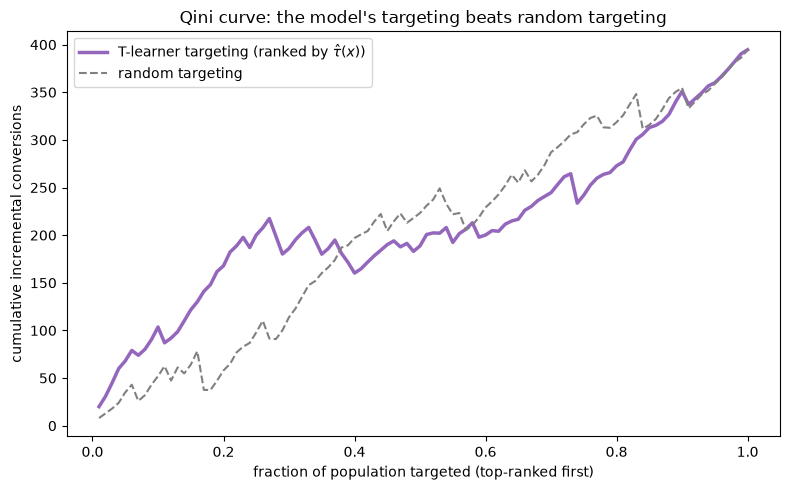

Mean qini value across targeted fractions -- model: 211.79, random: 204.73
Qini coefficient (model area above random targeting): 7.06


In [13]:

def qini_curve(y, t, tau_hat, n_points=100):
    order = np.argsort(-tau_hat)          # rank by predicted uplift, descending
    y_sorted, t_sorted = y[order], t[order]
    n = len(y_sorted)
    fracs = np.linspace(1 / n_points, 1.0, n_points)
    qini_vals = []
    for frac in fracs:
        k = max(int(round(frac * n)), 1)
        y_k, t_k = y_sorted[:k], t_sorted[:k]
        n1, n0 = t_k.sum(), (1 - t_k).sum()
        r1, r0 = y_k[t_k == 1].sum(), y_k[t_k == 0].sum()
        if n0 == 0:                        # too few controls in this slice to rescale safely
            qini_vals.append(np.nan)
        else:
            qini_vals.append(r1 - r0 * (n1 / n0))
    return fracs, np.array(qini_vals)


y_test = test_df["converted"].values
t_test = test_df["any_email"].values

fracs, qini_model = qini_curve(y_test, t_test, test_df["tau_hat_T"].values)
_, qini_random = qini_curve(y_test, t_test, rng.permutation(len(test_df)).astype(float))

# Overall incremental gain achieved at 100% targeting (same for every ranking -- it's just the ATE * N1)
overall_gain = qini_model[~np.isnan(qini_model)][-1]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(fracs, qini_model, color="tab:purple", lw=2.5, label="T-learner targeting (ranked by $\\hat\\tau(x)$)")
ax.plot(fracs, qini_random, color="gray", lw=1.5, linestyle="--", label="random targeting")
ax.set_xlabel("fraction of population targeted (top-ranked first)")
ax.set_ylabel("cumulative incremental conversions")
ax.set_title("Qini curve: the model's targeting beats random targeting")
ax.legend()
plt.tight_layout()
plt.savefig("qini_curve.png", dpi=130)
plt.show()

qini_auc_model = np.nanmean(qini_model)
qini_auc_random = np.nanmean(qini_random)
print(f"Mean qini value across targeted fractions -- model: {qini_auc_model:.2f}, random: {qini_auc_random:.2f}")
print(f"Qini coefficient (model area above random targeting): {qini_auc_model - qini_auc_random:.2f}")



**How to read this**: the purple curve sitting above the gray diagonal
means that if you target only the top-ranked fraction of customers by
predicted uplift, you capture *more* of the campaign's total incremental
conversions than targeting an equally-sized *random* slice of customers
would — i.e., the model successfully concentrates the persuadables near the
top of the ranking. The gap between the two curves (the **qini
coefficient**) is the standard single-number summary practitioners quote
when comparing uplift models against each other or against a "just email
everyone" baseline.

### 5.8 Is there a recognizable subgroup pattern?

Finally, a quick check of whether the estimated uplift correlates with any
one covariate — the kind of first pass a marketing analyst would run to
turn a CATE model into an actual targeting rule.


In [14]:

corr_table = test_df[["tau_hat_T", "age", "income", "insurance", "invested"]].corr()["tau_hat_T"].drop("tau_hat_T")
print("Correlation of predicted uplift with each covariate:")
print(corr_table.round(3))

# Split into income terciles and compare average predicted uplift.
test_df["income_tercile"] = pd.qcut(test_df["income"], 3, labels=["low income", "mid income", "high income"])
print("\nMean predicted uplift by income tercile:")
print(test_df.groupby("income_tercile", observed=True)["tau_hat_T"].mean().round(4))


Correlation of predicted uplift with each covariate:
age          0.120
income       0.212
insurance   -0.141
invested     0.241
Name: tau_hat_T, dtype: float64

Mean predicted uplift by income tercile:
income_tercile
low income     0.0391
mid income     0.0935
high income    0.1057
Name: tau_hat_T, dtype: float64



Whatever pattern shows up here is a hypothesis about who the
"persuadables" tend to be — it is not, by itself, proof of a causal
subgroup effect (see Limitations below on multiple-testing risk in exactly
this kind of post-hoc slicing).



## 6. Use cases

- **Marketing and promotions** (this tutorial's running example): deciding
  who to send a promotional email, discount code, or retention offer to —
  the entire point being to find persuadables and avoid sleeping dogs and
  sure things, which is exactly why uplift modeling grew up as a marketing
  discipline before spreading elsewhere.
- **Personalized medicine**: which patients benefit most from a given
  treatment or drug, versus patients for whom it does little or carries
  needless side-effect risk — the same T/S/X-learner machinery, with $Y$ as
  a clinical outcome instead of a conversion flag (this is precisely the
  applied setting Wager & Athey, 2018 target with causal forests).
- **Pricing and discount targeting**: estimating which customers' purchase
  decisions actually swing on a discount, versus customers who would pay
  full price anyway (the "sure thing" problem in its purest commercial
  form).
- **Churn-prevention interventions**: predicting which at-risk customers a
  retention call or offer will actually save, since blanket retention
  campaigns run into the same sleeping-dog risk as promotional email.
- **Policy targeting**: which claimants or participants benefit most from
  a job-training program — a direct callback to the NSW experiment in the
  fundamental-problem tutorial, whose ATE told us the program helped *on
  average* but not who it helped *most*, which is exactly the question a
  CATE analysis of that same dataset would answer.



## 7. Limitations & debates

- **CATE estimation needs substantially more statistical power than ATE
  estimation.** An ATE pools the entire sample into one number; a CATE
  effectively needs enough data *within every region of covariate space*
  to estimate $\tau(x)$ precisely there. The fundamental problem bites even
  harder here: you never observe any individual's true uplift to validate
  a prediction against directly, only *aggregate* validation tools like the
  qini curve above — there is no individual-level ground truth, ever, for
  any dataset, no matter how large.
- **Meta-learners can disagree with each other on the same data.** The
  T-learner, S-learner, and X-learner make different bias/variance
  tradeoffs depending on how imbalanced the treatment groups are and how
  well each nuisance model ($\mu_1$, $\mu_0$, and the propensity model) is
  specified. Künzel et al. (2019) and Curth & van der Schaar (2021) both
  benchmark this extensively and find **no universal winner** — which
  meta-learner performs best depends on the specific data-generating
  regime (group balance, effect sparsity, nonlinearity), not on the method
  alone. In this tutorial's dataset, the ~96%/4% treatment/control split is
  exactly the regime where a T-learner's control-arm model is trained on
  relatively few examples — the motivation for the X-learner's propensity
  reweighting in section 3.5.
- **Overfitting to noise, and "finding" spurious subgroups.** Section 5.8's
  income-tercile split is a single, honest look at one covariate. Nothing
  stops an analyst from slicing by ten covariates, reporting only the one
  that looks interesting, and calling it a discovered segment — a
  multiple-testing problem structurally identical to the one flagged in
  this repo's responsible-data-science tutorials. A model *will* produce a
  ranking and a "top segment" even on pure noise; always validate any
  claimed subgroup pattern out-of-sample (as we did by evaluating the qini
  curve on a held-out test set) before acting on it, and be skeptical of
  any single subgroup claim not backed by a pre-registered hypothesis or a
  qini-style aggregate check.
- **Ignorability is still required, and is not weakened by asking a richer
  question.** Every meta-learner in section 3 estimates $\tau(x)$ correctly
  only if $\{Y(0),Y(1)\} \perp T \mid X$ holds (section 3.6) — exactly the
  same assumption the fundamental-problem and propensity-score-matching
  tutorials rely on for the ATE. If treatment were observational rather
  than randomized and this assumption failed, the resulting bias would be
  **harder to detect** than ATE bias: an ATE analysis has one number to
  sanity-check (e.g. against a known benchmark or a balance test); a CATE
  analysis produces thousands of numbers, and a biased $\tau(x)$ can still
  look plausible, well-calibrated on average, and even produce a
  nice-looking qini curve on the same biased data, while being systematically
  wrong about *who* actually benefits.
- **A qini curve validates ranking quality, not causal correctness.** It
  can only be computed where treatment assignment is (or can credibly be
  treated as) ignorable in the evaluation data — a beautiful qini curve
  computed on confounded data is still confounded; it is a *calibration*
  check given the causal assumptions hold, not independent proof that they
  do.



## 8. References

- Künzel, S. R., Sekhon, J. S., Bickel, P. J., & Yu, B. (2019). *Metalearners
  for Estimating Heterogeneous Treatment Effects using Machine Learning.*
  PNAS 116(10). (T-/S-/X-learner framework)
- Radcliffe, N. J. & Surry, P. D. (2011). *Real-World Uplift Modelling with
  Significance-Based Uplift Trees.* Portrait Technical Report. (origin of
  qini curve terminology)
- Wager, S. & Athey, S. (2018). *Estimation and Inference of Heterogeneous
  Treatment Effects using Random Forests.* JASA 113(523).
- Curth, A. & van der Schaar, M. (2021). *Nonparametric Estimation of
  Heterogeneous Treatment Effects: From Theory to Learning Algorithms.*
  AISTATS 2021.
- Facure, M. *Causal Inference for the Brave and True*
  (matheusfacure.github.io/python-causality-handbook) — source of the
  `invest_email_rnd.csv` dataset used here.
- Battocchi, K. et al. (2019). *EconML: A Python Package for ML-Based
  Heterogeneous Treatment Effects Estimation.* Microsoft Research.
  github.com/py-why/econml.
- Holland, P. W. (1986). *Statistics and Causal Inference.* JASA 81(396).
  (potential-outcomes framework this tutorial builds on)
